# Klasifikasi Risiko Penyakit Jantung Menggunakan Algoritma Machine Learning: Studi Komparatif

---

**Mata Kuliah** : Machine Learning — IF2514403  
**Kelompok** : [Nomor Kelompok]  
**Anggota** :
1. [Nama Lengkap] — [NIM]
2. [Nama Lengkap] — [NIM]
3. [Nama Lengkap] — [NIM]

**Referensi Jurnal** :  
Chulde-Fernández, B., Enríquez-Ortega, D., Guevara, C., Navas, P., Tirado-Espín, A., Vizcaíno-Imacaña, P., Villalba-Meneses, F., Cadena-Morejon, C., Almeida-Galarraga, D., & Acosta-Vargas, P. (2025). *Classification of Heart Failure Using Machine Learning: A Comparative Study*. MDPI Life, 15(3), 496. https://doi.org/10.3390/life15030496

**Dataset** : Heart Failure Prediction Dataset (fedesoriano, Kaggle)  
**Link Dataset** : https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

---

## Latar Belakang

Penyakit kardiovaskular, khususnya gagal jantung, merupakan salah satu penyebab kematian tertinggi secara global. Menurut data World Health Organization, penyakit ini bertanggung jawab atas sekitar 17,9 juta kematian per tahun atau setara dengan 32% dari total kematian global. Kondisi ini seringkali tidak terdeteksi hingga stadium lanjut karena gejala awalnya yang tidak spesifik, sehingga deteksi dini berbasis data klinis menjadi sangat relevan.

Jurnal referensi yang digunakan pada proyek ini mengevaluasi beberapa algoritma klasifikasi machine learning untuk memprediksi risiko penyakit jantung berdasarkan data klinis pasien. Notebook ini mereplikasi dan mengadaptasi metodologi dari jurnal tersebut menggunakan dataset publik dari Kaggle, dengan tujuan membandingkan performa minimal empat algoritma klasifikasi secara komprehensif — mulai dari eksperimen baseline hingga optimasi hyperparameter.

## Alur Kerja Notebook

1. Persiapan lingkungan dan import library
2. Akuisisi dataset via Kaggle API
3. Eksplorasi data awal (Exploratory Data Analysis)
4. Pra-pemrosesan data (Preprocessing)
5. Eksperimen baseline — pelatihan dan evaluasi model awal
6. Integrasi metode dari jurnal referensi
7. Optimasi hyperparameter (GridSearchCV)
8. Perbandingan performa akhir
9. Kendala teknis dan analisis error
10. Kesimpulan dan rencana tindak lanjut

---
## Bagian 1 — Persiapan Lingkungan dan Import Library

Seluruh library yang digunakan pada notebook ini tersedia secara default di lingkungan Google Colab. Tidak diperlukan instalasi tambahan. Berikut adalah deskripsi singkat fungsi masing-masing library:

- **pandas** : manipulasi dan analisis data berbasis DataFrame. Digunakan untuk hampir seluruh operasi pembacaan, filtering, dan transformasi data tabular.
- **numpy** : komputasi numerik berbasis array. Digunakan untuk operasi matematika dan manipulasi matriks.
- **matplotlib dan seaborn** : library visualisasi data. Matplotlib menyediakan kontrol grafik tingkat rendah, sedangkan seaborn menyederhanakan pembuatan grafik statistik.
- **scikit-learn** : library utama machine learning di Python. Menyediakan implementasi algoritma klasifikasi, modul preprocessing, pembagian data, evaluasi model, dan pencarian hyperparameter.

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Seluruh library berhasil diimport.')

Seluruh library berhasil diimport.


---
## Bagian 2 — Akuisisi Dataset via Kaggle API

Dataset yang digunakan adalah **Heart Failure Prediction Dataset** yang dikurasi oleh fedesoriano dan dipublikasikan di Kaggle. Dataset ini merupakan hasil konsolidasi dari lima dataset jantung publik yang sebelumnya tersebar secara terpisah, yaitu: Cleveland Heart Disease, Hungarian Institute of Cardiology Budapest, Swiss Hospital Basel, Long Beach VA, dan Stalog Heart Dataset. Penggabungan ini menghasilkan dataset dengan total 918 observasi yang menjadikannya salah satu dataset penyakit jantung terbesar yang tersedia secara publik.

Untuk mengakses dataset secara langsung dari Kaggle ke lingkungan Google Colab tanpa perlu mengunduh file secara manual, digunakan Kaggle API. Mekanisme kerjanya adalah sebagai berikut:

1. File `kaggle.json` yang berisi API token diperoleh dari halaman pengaturan akun Kaggle (Settings > API > Create New Token).
2. File tersebut diunggah ke Colab, kemudian dipindahkan ke direktori `/root/.kaggle/` agar dapat dikenali oleh Kaggle CLI.
3. Perintah `kaggle datasets download` dijalankan untuk mengunduh dan mengekstrak dataset langsung ke environment aktif.

Pendekatan ini memungkinkan seluruh alur kerja direproduksi ulang hanya dengan menjalankan kembali notebook dari awal, tanpa ketergantungan pada file lokal di komputer peneliti.

In [ ]:
# Autentikasi Kaggle API.
# File kaggle.json yang diunggah dipindahkan ke direktori /root/.kaggle/
# yang merupakan lokasi default yang dibaca oleh Kaggle CLI.
# Permission 0o600 memastikan file hanya dapat dibaca oleh pemilik,
# sesuai persyaratan keamanan yang diterapkan oleh Kaggle.

from google.colab import files
import os

print('Upload file kaggle.json untuk autentikasi Kaggle API.')
files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Autentikasi Kaggle API berhasil dikonfigurasi.')

Upload file kaggle.json untuk autentikasi Kaggle API.


Saving kaggle.json to kaggle.json
Autentikasi Kaggle API berhasil dikonfigurasi.


In [ ]:
# Dataset diunduh menggunakan Kaggle CLI dengan flag --unzip
# agar file CSV langsung tersedia tanpa langkah dekompresi manual.
# Flag -p . menentukan direktori tujuan unduhan adalah direktori kerja aktif.

!kaggle datasets download -d fedesoriano/heart-failure-prediction -p . --unzip

print('\nFile yang tersedia setelah unduhan:')
!ls -lh *.csv

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
License(s): ODbL-1.0
100% 8.56k/8.56k [00:00<00:00, 17.5MB/s]


File yang tersedia setelah unduhan:
-rw-r--r-- 1 root root 36K Apr 29 05:49 heart.csv


In [ ]:
# Dataset dibaca ke dalam pandas DataFrame.
# Dimensi data dan nama kolom ditampilkan sebagai verifikasi awal
# bahwa file berhasil dimuat dengan benar.

df = pd.read_csv('heart.csv')

print(f'Dataset berhasil dimuat.')
print(f'Dimensi  : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Kolom    : {list(df.columns)}')

Dataset berhasil dimuat.
Dimensi  : 918 baris x 12 kolom
Kolom    : ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [ ]:
# Lima baris pertama dataset ditampilkan untuk mendapatkan gambaran
# awal mengenai struktur data, format nilai, dan tipe data setiap kolom.

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5000,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0000,Up,0


---
## Bagian 3 — Eksplorasi Data Awal (Exploratory Data Analysis)

Exploratory Data Analysis merupakan tahap investigasi awal yang bertujuan untuk memahami karakteristik dataset sebelum pemodelan dilakukan. Tujuan utama EDA pada notebook ini adalah:

1. Memeriksa struktur data — tipe data setiap kolom dan keberadaan nilai hilang.
2. Memahami distribusi statistik setiap variabel.
3. Mendeteksi anomali atau nilai tidak valid yang perlu ditangani pada tahap preprocessing.
4. Menganalisis distribusi kelas target untuk mendeteksi ketidakseimbangan kelas.
5. Mengidentifikasi fitur-fitur yang memiliki korelasi kuat dengan variabel target.

### Deskripsi Variabel Dataset

| Variabel | Tipe | Deskripsi |
|---|---|---|
| Age | Numerik | Usia pasien dalam tahun |
| Sex | Kategorikal | Jenis kelamin (M = Male, F = Female) |
| ChestPainType | Kategorikal | Tipe nyeri dada: ATA (Atypical Angina), NAP (Non-Anginal Pain), ASY (Asymptomatic), TA (Typical Angina) |
| RestingBP | Numerik | Tekanan darah saat istirahat dalam mmHg |
| Cholesterol | Numerik | Kadar kolesterol serum dalam mg/dl |
| FastingBS | Biner | Gula darah puasa lebih dari 120 mg/dl: 1 = Ya, 0 = Tidak |
| RestingECG | Kategorikal | Hasil elektrokardiogram saat istirahat |
| MaxHR | Numerik | Detak jantung maksimum yang dicapai |
| ExerciseAngina | Kategorikal | Angina yang dipicu olahraga: Y = Ya, N = Tidak |
| Oldpeak | Numerik | Nilai ST depression relatif terhadap kondisi istirahat |
| ST_Slope | Kategorikal | Kemiringan segmen ST pada puncak latihan |
| HeartDisease | **Target** | **1 = Penyakit jantung terdeteksi, 0 = Normal** |

In [ ]:
# df.info() menampilkan ringkasan teknis dataset:
# tipe data setiap kolom, jumlah nilai non-null, serta estimasi penggunaan memori.
# Langkah ini penting untuk mengidentifikasi kolom dengan tipe data yang
# tidak sesuai atau yang mengandung missing values tersirat.

print('Informasi struktur dataset:')
print('=' * 55)
df.info()

Informasi struktur dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Pemeriksaan missing values eksplisit menggunakan isnull().sum().
# Kolom Cholesterol dengan nilai 0 tidak akan terdeteksi di sini karena
# bukan merupakan NaN — namun akan ditangani pada tahap preprocessing
# sebagai outlier medis yang tidak valid.

missing_vals = df.isnull().sum()
missing_pct  = (missing_vals / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing Values' : missing_vals,
    'Persentase (%)'        : missing_pct
})

print('Ringkasan Missing Values per Kolom:')
print('=' * 42)
print(missing_df)
print('=' * 42)

if missing_vals.sum() == 0:
    print('\nTidak ditemukan missing values (NaN) pada dataset ini.')
    print('Catatan: nilai Cholesterol = 0 akan diidentifikasi sebagai anomali medis')
    print('         dan ditangani secara terpisah pada tahap preprocessing.')
else:
    print(f'\nTotal missing values yang ditemukan: {missing_vals.sum()}')

Ringkasan Missing Values per Kolom:
                Jumlah Missing Values  Persentase (%)
Age                                 0          0.0000
Sex                                 0          0.0000
ChestPainType                       0          0.0000
RestingBP                           0          0.0000
Cholesterol                         0          0.0000
FastingBS                           0          0.0000
RestingECG                          0          0.0000
MaxHR                               0          0.0000
ExerciseAngina                      0          0.0000
Oldpeak                             0          0.0000
ST_Slope                            0          0.0000
HeartDisease                        0          0.0000

Tidak ditemukan missing values (NaN) pada dataset ini.
Catatan: nilai Cholesterol = 0 akan diidentifikasi sebagai anomali medis
         dan ditangani secara terpisah pada tahap preprocessing.


In [ ]:
# Statistik deskriptif memberikan ringkasan numerik untuk setiap kolom:
# count, mean, standar deviasi, nilai minimum, kuartil pertama (25%),
# median (50%), kuartil ketiga (75%), dan nilai maksimum.
#
# Perhatikan kolom Cholesterol — nilai minimum 0 merupakan anomali
# yang akan ditangani pada tahap preprocessing.
# Perhatikan juga RestingBP dengan nilai minimum 0 yang perlu dievaluasi.

print('Statistik deskriptif dataset:')
df.describe().round(2)

Statistik deskriptif dataset:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.0000,918.0000,918.0000,918.0000,918.0000,918.0000,918.0000
mean,53.5100,132.4000,198.8000,0.2300,136.8100,0.8900,0.5500
std,9.4300,18.5100,109.3800,0.4200,25.4600,1.0700,0.5000
min,28.0000,0.0000,0.0000,0.0000,60.0000,-2.6000,0.0000
25%,47.0000,120.0000,173.2500,0.0000,120.0000,0.0000,0.0000
50%,54.0000,130.0000,223.0000,0.0000,138.0000,0.6000,1.0000
75%,60.0000,140.0000,267.0000,0.0000,156.0000,1.5000,1.0000
max,77.0000,200.0000,603.0000,1.0000,202.0000,6.2000,1.0000


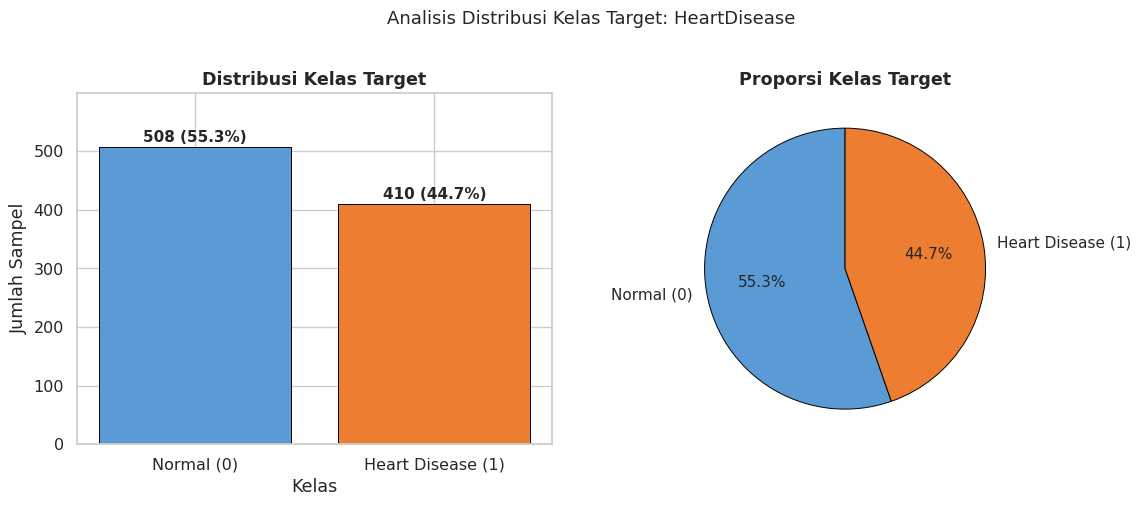

Distribusi kelas:
  Normal (0)        : 410 sampel (44.7%)
  Heart Disease (1) : 508 sampel (55.3%)

Rasio kelas mayoritas terhadap minoritas : 1.24:1

Distribusi kelas relatif seimbang (rasio < 1.5:1).
Teknik penanganan imbalance seperti SMOTE tidak diperlukan pada dataset ini.
Stratified split tetap diterapkan untuk mempertahankan proporsi kelas di kedua set.


In [ ]:
# Distribusi kelas target diperiksa untuk mendeteksi class imbalance.
# Ketidakseimbangan yang signifikan — umumnya rasio lebih dari 3:1 —
# dapat menyebabkan model bias terhadap kelas mayoritas dan memerlukan
# penanganan khusus seperti SMOTE, class_weight, atau threshold tuning.

target_counts = df['HeartDisease'].value_counts()
labels        = ['Normal (0)', 'Heart Disease (1)']
colors        = ['#5B9BD5', '#ED7D31']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(target_counts.values) * 1.18)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 8, f'{v} ({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.7},
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target')

plt.suptitle('Analisis Distribusi Kelas Target: HeartDisease', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

ratio = max(target_counts.values) / min(target_counts.values)
print(f'Distribusi kelas:')
print(f'  Normal (0)        : {target_counts[0]} sampel ({target_counts[0]/len(df)*100:.1f}%)')
print(f'  Heart Disease (1) : {target_counts[1]} sampel ({target_counts[1]/len(df)*100:.1f}%)')
print(f'\nRasio kelas mayoritas terhadap minoritas : {ratio:.2f}:1')
print()
if ratio < 1.5:
    print('Distribusi kelas relatif seimbang (rasio < 1.5:1).')
    print('Teknik penanganan imbalance seperti SMOTE tidak diperlukan pada dataset ini.')
    print('Stratified split tetap diterapkan untuk mempertahankan proporsi kelas di kedua set.')
else:
    print('Terdeteksi ketidakseimbangan kelas. Pertimbangkan penerapan SMOTE atau class_weight.')

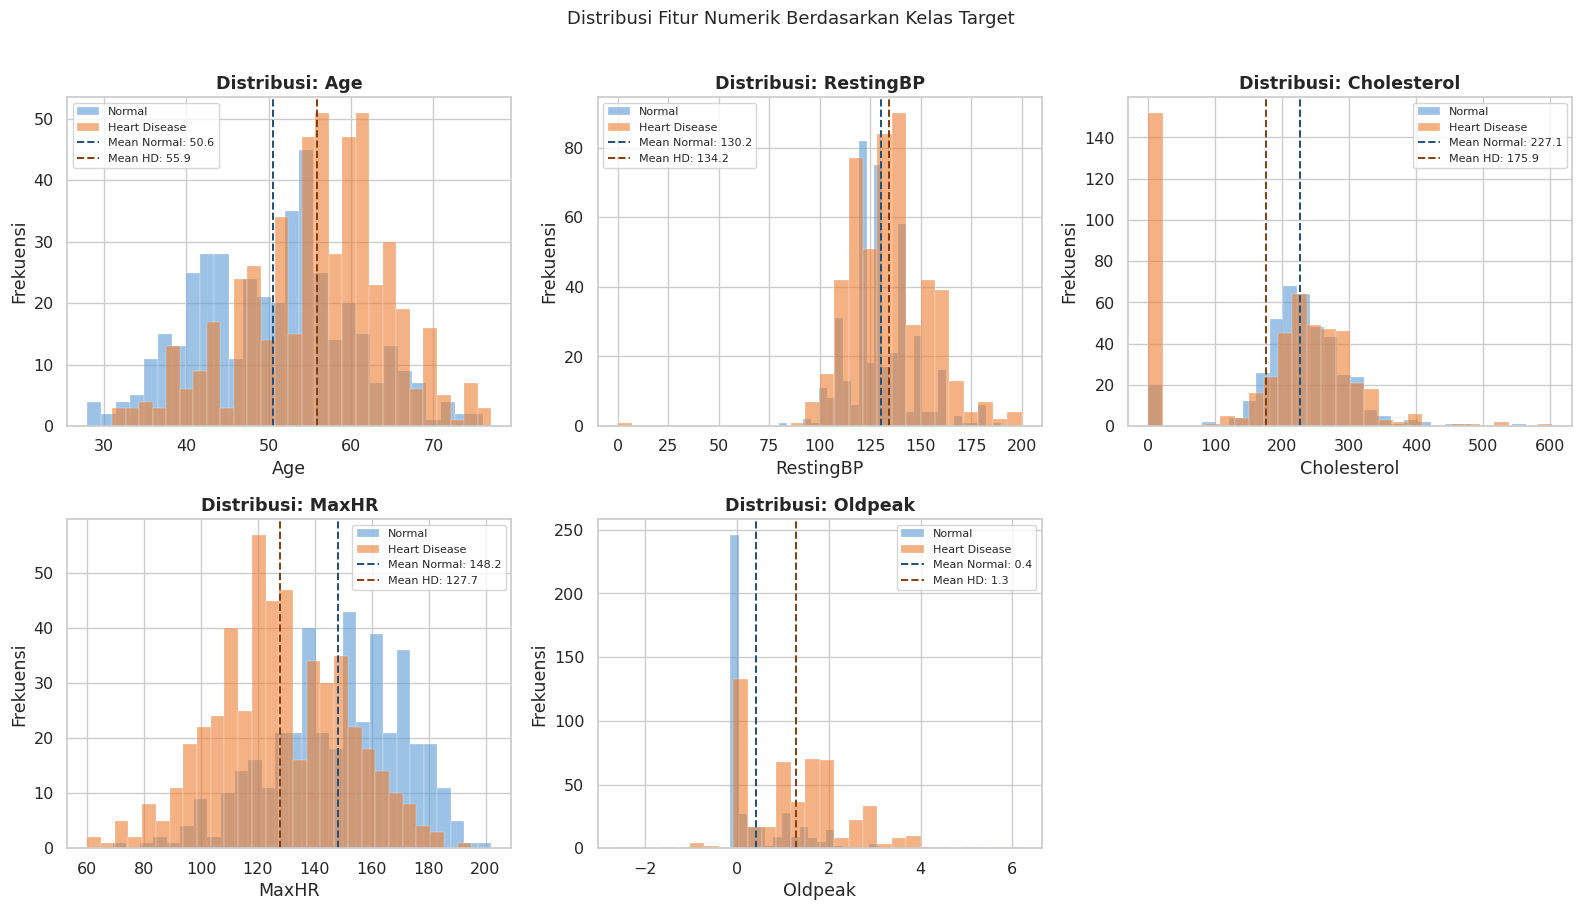

Temuan dari distribusi fitur numerik:
  MaxHR     : pasien dengan penyakit jantung memiliki detak jantung maksimum yang lebih rendah.
  Oldpeak   : nilai ST depression cenderung lebih tinggi pada pasien penyakit jantung.
  Age       : pasien penyakit jantung rata-rata berusia lebih tua.
  Cholesterol : distribusi kedua kelas tumpang tindih — daya prediktif relatif lebih lemah.


In [ ]:
# Distribusi fitur numerik divisualisasikan menggunakan histogram yang
# dipisahkan berdasarkan kelas target. Pendekatan ini memungkinkan
# identifikasi fitur yang memiliki distribusi berbeda secara signifikan
# antara kelas Normal dan Heart Disease — yang mengindikasikan
# daya prediktif fitur tersebut terhadap target.

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    normal = df[df['HeartDisease'] == 0][col]
    hd     = df[df['HeartDisease'] == 1][col]

    axes[i].hist(normal, alpha=0.60, label='Normal', color='#5B9BD5', bins=28,
                 edgecolor='white', linewidth=0.3)
    axes[i].hist(hd, alpha=0.60, label='Heart Disease', color='#ED7D31', bins=28,
                 edgecolor='white', linewidth=0.3)
    axes[i].axvline(normal.mean(), color='#1F4E79', linestyle='--', linewidth=1.4,
                    label=f'Mean Normal: {normal.mean():.1f}')
    axes[i].axvline(hd.mean(), color='#843C0C', linestyle='--', linewidth=1.4,
                    label=f'Mean HD: {hd.mean():.1f}')
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik Berdasarkan Kelas Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Temuan dari distribusi fitur numerik:')
print('  MaxHR     : pasien dengan penyakit jantung memiliki detak jantung maksimum yang lebih rendah.')
print('  Oldpeak   : nilai ST depression cenderung lebih tinggi pada pasien penyakit jantung.')
print('  Age       : pasien penyakit jantung rata-rata berusia lebih tua.')
print('  Cholesterol : distribusi kedua kelas tumpang tindih — daya prediktif relatif lebih lemah.')

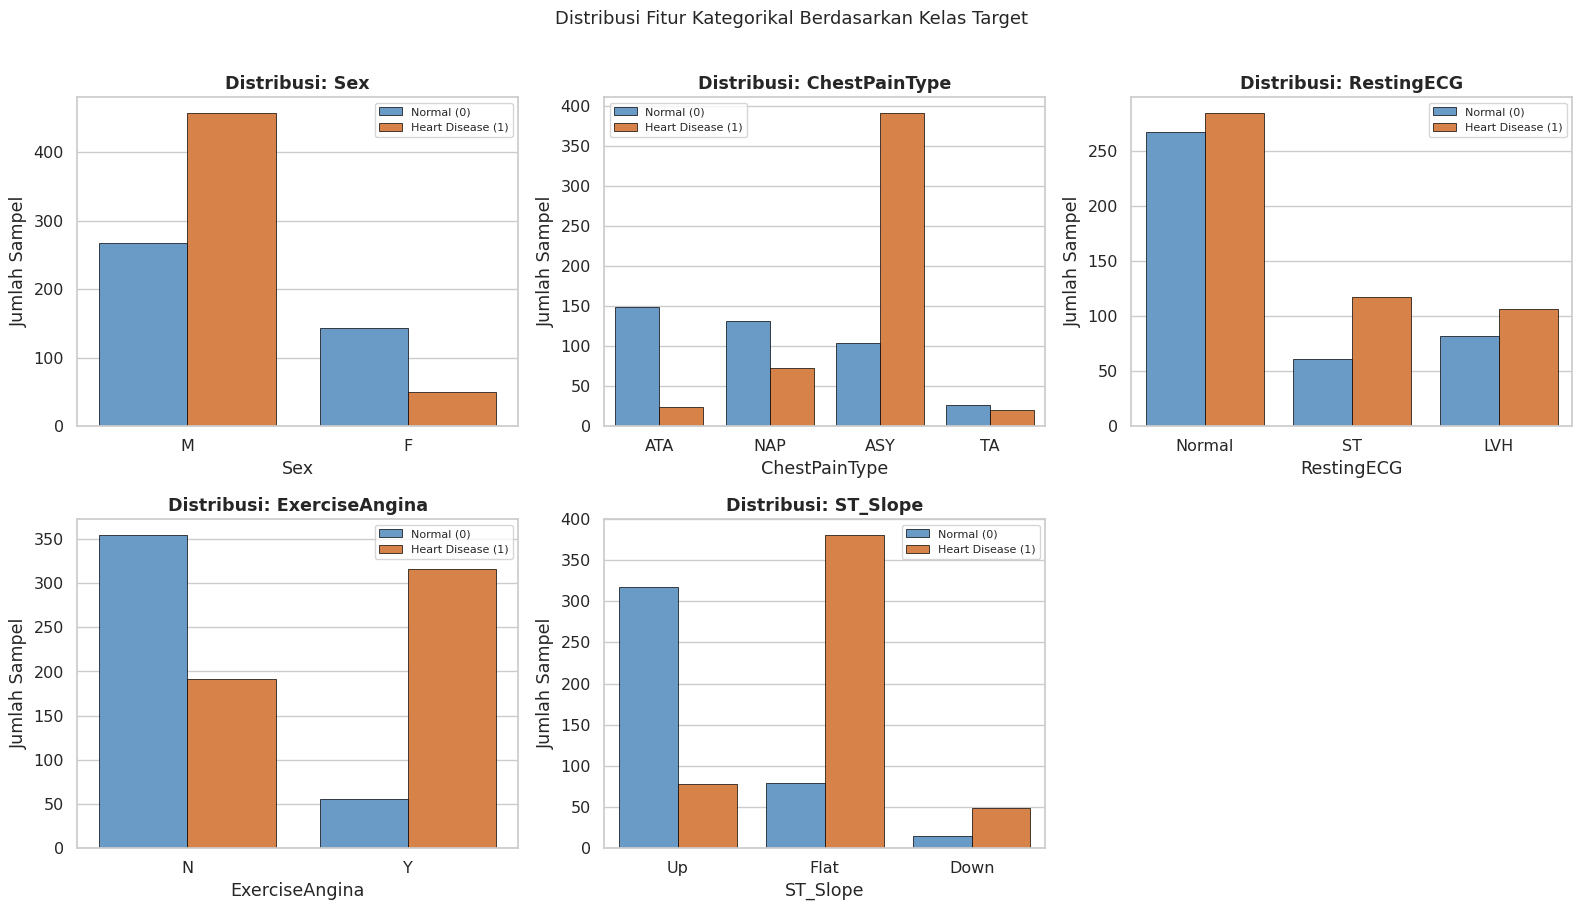

Temuan dari distribusi fitur kategorikal:
  ChestPainType ASY  : tipe nyeri dada asimptomatik paling banyak berasosiasi dengan HD.
  ExerciseAngina Y   : mayoritas pasien yang mengalami angina saat olahraga didiagnosis HD.
  ST_Slope Flat      : kemiringan segmen ST datar dominan pada kelompok HD.


In [ ]:
# Distribusi fitur kategorikal divisualisasikan menggunakan countplot
# dengan parameter hue untuk memisahkan setiap batang berdasarkan kelas target.
# Ini membantu mengidentifikasi kategori mana yang secara proporsional
# lebih banyak berasosiasi dengan penyakit jantung.

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease',
                  palette={0: '#5B9BD5', 1: '#ED7D31'},
                  ax=axes[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Sampel')
    handles, _ = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ['Normal (0)', 'Heart Disease (1)'], fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal Berdasarkan Kelas Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Temuan dari distribusi fitur kategorikal:')
print('  ChestPainType ASY  : tipe nyeri dada asimptomatik paling banyak berasosiasi dengan HD.')
print('  ExerciseAngina Y   : mayoritas pasien yang mengalami angina saat olahraga didiagnosis HD.')
print('  ST_Slope Flat      : kemiringan segmen ST datar dominan pada kelompok HD.')

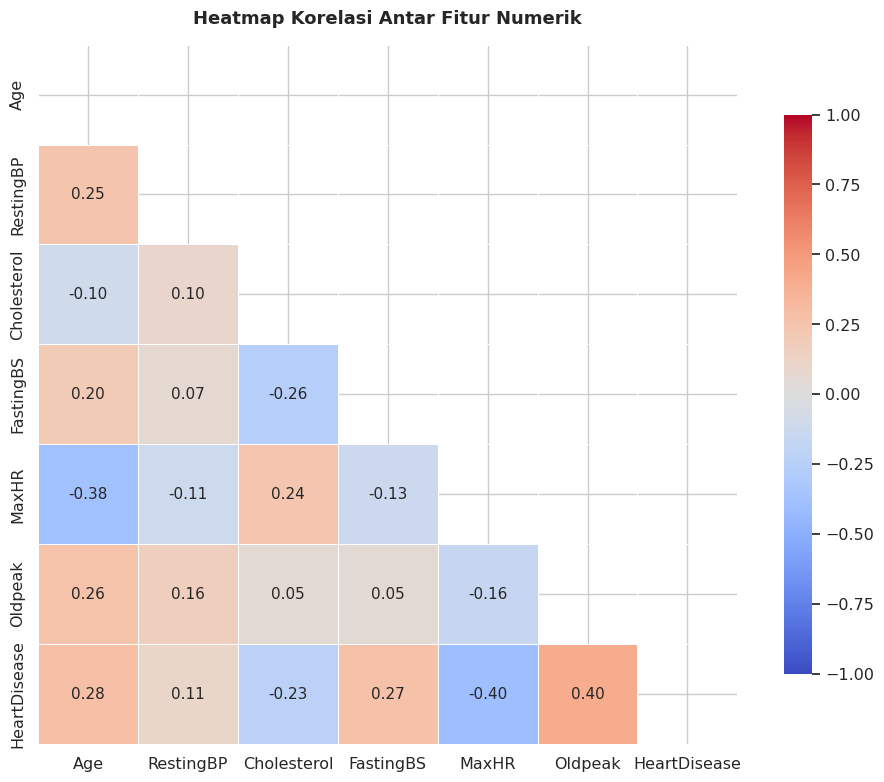

Korelasi fitur numerik terhadap HeartDisease (diurutkan berdasarkan nilai absolut):
  Oldpeak         : +0.4040  (korelasi positif)
  MaxHR           : -0.4004  (korelasi negatif)
  Age             : +0.2820  (korelasi positif)
  FastingBS       : +0.2673  (korelasi positif)
  Cholesterol     : -0.2327  (korelasi negatif)
  RestingBP       : +0.1076  (korelasi positif)


In [ ]:
# Heatmap korelasi menampilkan koefisien korelasi Pearson antar variabel numerik.
# Nilai mendekati +1 atau -1 menunjukkan korelasi linear yang kuat,
# sedangkan nilai mendekati 0 menunjukkan tidak ada korelasi linear.
# Korelasi terhadap kolom HeartDisease mengindikasikan daya prediktif
# masing-masing fitur secara individual.

num_for_corr = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
corr_matrix  = df[num_for_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})

plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
print('Korelasi fitur numerik terhadap HeartDisease (diurutkan berdasarkan nilai absolut):')
for feat, val in target_corr.items():
    direction = 'positif' if val > 0 else 'negatif'
    print(f'  {feat:<15} : {val:+.4f}  (korelasi {direction})')

---
## Bagian 4 — Pra-Pemrosesan Data (Preprocessing)

Tahap preprocessing bertujuan untuk menyiapkan data mentah agar dapat diproses secara optimal oleh algoritma machine learning. Empat tahapan preprocessing dilakukan pada notebook ini:

### 4.1 Encoding Fitur Kategorikal
Algoritma machine learning memerlukan input berupa nilai numerik. Kolom-kolom kategorikal bertipe string dikonversi menggunakan **Label Encoding**, di mana setiap kategori unik dipetakan ke bilangan bulat. Metode ini dipilih karena semua kolom kategorikal pada dataset ini bersifat nominal tanpa urutan inheren yang memerlukan representasi ordinal.

### 4.2 Penanganan Nilai Anomali (Outlier Medis)
Berdasarkan hasil EDA, kolom `Cholesterol` memiliki sejumlah entri bernilai 0 yang tidak mungkin secara medis — kolesterol 0 mg/dl tidak dapat terjadi pada makhluk hidup. Nilai-nilai ini diperlakukan sebagai *missing at random* dan diimputasi menggunakan **nilai median** dari sampel yang valid. Median dipilih karena lebih robust terhadap distribusi yang tidak simetris dibandingkan mean.

### 4.3 Pemisahan Fitur dan Target, serta Train-Test Split
Dataset dibagi menjadi set pelatihan (80%) dan set pengujian (20%) menggunakan **stratified sampling** untuk mempertahankan proporsi kelas yang representatif di kedua subset.

### 4.4 Standarisasi Fitur
**StandardScaler** digunakan untuk mentransformasi setiap fitur numerik sehingga memiliki mean = 0 dan standar deviasi = 1. Standarisasi ini krusial untuk algoritma berbasis jarak seperti K-Nearest Neighbors, serta algoritma yang menggunakan regularisasi seperti Logistic Regression. Scaler hanya di-*fit* pada data training untuk mencegah *data leakage*.

In [ ]:
# Label Encoding diterapkan pada seluruh kolom kategorikal.
# Setiap instance LabelEncoder disimpan dalam dictionary
# untuk keperluan inverse transform jika dibutuhkan di kemudian hari.
# Proses dilakukan pada salinan dataset (df_processed) agar
# data asli tetap tersimpan untuk referensi atau visualisasi lanjutan.

df_processed = df.copy()
cat_cols      = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}

print('Label Encoding pada fitur kategorikal:')
print('=' * 55)
for col in cat_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:<20} : {mapping}')

print('=' * 55)
print('\nDataset setelah encoding (5 baris pertama):')
df_processed[cat_cols].head()

Label Encoding pada fitur kategorikal:
  Sex                  : {'F': np.int64(0), 'M': np.int64(1)}
  ChestPainType        : {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
  RestingECG           : {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
  ExerciseAngina       : {'N': np.int64(0), 'Y': np.int64(1)}
  ST_Slope             : {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}

Dataset setelah encoding (5 baris pertama):


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,1,1,1,0,2
1,0,2,1,0,1
2,1,1,2,0,2
3,0,0,1,1,1
4,1,2,1,0,2


In [ ]:
# Penanganan nilai Cholesterol = 0 yang tidak valid secara medis.
# Nilai 0 pada kolom ini bukan merupakan NaN sehingga tidak terdeteksi
# oleh pemeriksaan missing values standar. Nilai-nilai ini diimputasi
# menggunakan median kolesterol dari sampel yang valid (nilai > 0).
#
# Perlu dicatat bahwa imputasi median merupakan pendekatan konservatif.
# Pada proyek akhir, dapat dipertimbangkan teknik imputasi yang lebih
# canggih seperti KNN Imputer atau Multiple Imputation by Chained Equations.

invalid_count = (df_processed['Cholesterol'] == 0).sum()
print(f'Jumlah entri Cholesterol = 0 (tidak valid secara medis) : {invalid_count} baris')
print(f'Persentase terhadap total dataset                       : {invalid_count/len(df_processed)*100:.1f}%')

valid_median = df_processed[df_processed['Cholesterol'] > 0]['Cholesterol'].median()
print(f'\nMedian Cholesterol dari sampel valid : {valid_median:.1f} mg/dl')

df_processed['Cholesterol'] = df_processed['Cholesterol'].replace(0, valid_median)

print(f'\nStatistik Cholesterol setelah imputasi:')
print(df_processed['Cholesterol'].describe().round(2))
print(f'\nVerifikasi — entri Cholesterol = 0 yang tersisa : {(df_processed["Cholesterol"] == 0).sum()}')

Jumlah entri Cholesterol = 0 (tidak valid secara medis) : 172 baris
Persentase terhadap total dataset                       : 18.7%

Median Cholesterol dari sampel valid : 237.0 mg/dl

Statistik Cholesterol setelah imputasi:
count   918.0000
mean    243.2000
std      53.4000
min      85.0000
25%     214.0000
50%     237.0000
75%     267.0000
max     603.0000
Name: Cholesterol, dtype: float64

Verifikasi — entri Cholesterol = 0 yang tersisa : 0


In [ ]:
# Pemisahan matriks fitur (X) dan vektor target (y).
# X berisi 11 fitur prediktor; y berisi label biner HeartDisease.

X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

print(f'Dimensi matriks fitur X : {X.shape}  ({X.shape[0]} sampel, {X.shape[1]} fitur)')
print(f'Dimensi vektor target y : {y.shape}  ({y.shape[0]} label)')
print(f'\nDaftar fitur prediktor:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Dimensi matriks fitur X : (918, 11)  (918 sampel, 11 fitur)
Dimensi vektor target y : (918,)  (918 label)

Daftar fitur prediktor:
   1. Age
   2. Sex
   3. ChestPainType
   4. RestingBP
   5. Cholesterol
   6. FastingBS
   7. RestingECG
   8. MaxHR
   9. ExerciseAngina
  10. Oldpeak
  11. ST_Slope


In [ ]:
# Pembagian data menggunakan rasio 80:20 dengan stratified split.
# Parameter stratify=y memastikan proporsi kelas pada training dan testing
# mencerminkan distribusi pada dataset asli.
# random_state=42 digunakan untuk reprodusibilitas hasil.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Hasil pembagian data:')
print(f'  Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Testing set  : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

train_dist = y_train.value_counts(normalize=True)
test_dist  = y_test.value_counts(normalize=True)
print(f'\nDistribusi kelas — Training set : Normal {train_dist[0]*100:.1f}% | HD {train_dist[1]*100:.1f}%')
print(f'Distribusi kelas — Testing set  : Normal {test_dist[0]*100:.1f}% | HD {test_dist[1]*100:.1f}%')
print('\nStratified split berhasil — proporsi kelas konsisten di kedua set.')

Hasil pembagian data:
  Training set : 734 sampel (80%)
  Testing set  : 184 sampel (20%)

Distribusi kelas — Training set : Normal 44.7% | HD 55.3%
Distribusi kelas — Testing set  : Normal 44.6% | HD 55.4%

Stratified split berhasil — proporsi kelas konsisten di kedua set.


In [ ]:
# StandardScaler mentransformasi setiap fitur sehingga memiliki mean = 0
# dan standar deviasi = 1. Ini penting terutama untuk KNN (berbasis jarak)
# dan Logistic Regression (menggunakan regularisasi L2 secara default).
#
# Aturan kritis: fit_transform() HANYA pada training data.
# transform() pada testing data menggunakan parameter dari training.
# Melakukan fit pada testing data adalah bentuk data leakage.

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print('Verifikasi hasil StandardScaler pada data training:')
print(f'  Mean   (seharusnya mendekati 0) : {X_train_scaled_df.mean().mean():.8f}')
print(f'  Std    (seharusnya mendekati 1) : {X_train_scaled_df.std().mean():.8f}')

print('\nPerbandingan nilai sebelum dan sesudah scaling — 5 sampel pertama, fitur Age:')
age_idx = list(X.columns).index('Age')
comp    = pd.DataFrame({
    'Age (Sebelum Scaling)' : X_train['Age'].values[:5],
    'Age (Setelah Scaling)' : X_train_scaled[:5, age_idx].round(4)
})
print(comp.to_string(index=False))
print('\nPreprocessing selesai. Data siap untuk pelatihan model.')

Verifikasi hasil StandardScaler pada data training:
  Mean   (seharusnya mendekati 0) : -0.00000000
  Std    (seharusnya mendekati 1) : 1.00068190

Perbandingan nilai sebelum dan sesudah scaling — 5 sampel pertama, fitur Age:
 Age (Sebelum Scaling)  Age (Setelah Scaling)
                    63                 0.9700
                    55                 0.1220
                    59                 0.5460
                    47                -0.7260
                    50                -0.4080

Preprocessing selesai. Data siap untuk pelatihan model.


---
## Bagian 5 — Eksperimen Baseline

Eksperimen baseline bertujuan untuk menetapkan patokan performa awal (benchmark) sebelum dilakukan optimasi lebih lanjut. Empat algoritma klasifikasi dilatih menggunakan parameter default dari scikit-learn, yang merepresentasikan pendekatan beragam dalam machine learning:

| Algoritma | Pendekatan | Catatan |
|---|---|---|
| Logistic Regression | Model linear probabilistik | Baseline standar untuk klasifikasi biner; interpretatif dan cepat |
| Decision Tree | Pohon keputusan berbasis aturan | Mudah divisualisasikan; rentan overfitting dengan parameter default |
| Random Forest | Ensemble dari banyak Decision Tree | Umumnya performa tinggi; robust terhadap overfitting |
| K-Nearest Neighbors | Klasifikasi berbasis kemiripan | Non-parametrik; sensitif terhadap scaling dan dimensionalitas |

Semua model dilatih pada data training yang telah distandarisasi dan dievaluasi pada data testing yang belum pernah dilihat oleh model.

In [ ]:
# Definisi dan pelatihan keempat model baseline.
# Parameter default digunakan secara konsisten pada semua model
# untuk menghasilkan perbandingan yang adil sebelum tahap tuning.
# max_iter=1000 pada LogisticRegression untuk memastikan konvergensi.

baseline_models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5)
}

trained_baseline = {}

print('Pelatihan model baseline:')
print('=' * 58)
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    trained_baseline[name] = model
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    print(f'  {name:<25} selesai  |  Accuracy: {acc:.4f} ({acc*100:.2f}%)')

print('=' * 58)
print('Evaluasi mendetail dilakukan pada sub-bagian berikut.')

Pelatihan model baseline:
  Logistic Regression       selesai  |  Accuracy: 0.8478 (84.78%)
  Decision Tree             selesai  |  Accuracy: 0.7663 (76.63%)
  Random Forest             selesai  |  Accuracy: 0.8587 (85.87%)
  K-Nearest Neighbors       selesai  |  Accuracy: 0.8587 (85.87%)
Evaluasi mendetail dilakukan pada sub-bagian berikut.


In [ ]:
# Evaluasi lengkap setiap model baseline menggunakan seluruh metrik
# yang relevan untuk konteks klasifikasi medis.
# cross_val_score dengan StratifiedKFold (5 fold) memberikan estimasi
# performa yang lebih stabil dan tidak bergantung pada satu pembagian data.

skf             = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = []

print('Evaluasi lengkap model baseline:')
print('=' * 68)

for name, model in trained_baseline.items():
    y_pred    = model.predict(X_test_scaled)
    y_prob    = model.predict_proba(X_test_scaled)[:, 1]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

    baseline_results.append({
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_test, y_pred), 4),
        'Precision'  : round(precision_score(y_test, y_pred), 4),
        'Recall'     : round(recall_score(y_test, y_pred), 4),
        'F1-Score'   : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'    : round(roc_auc_score(y_test, y_prob), 4),
        'CV-5 Mean'  : round(cv_scores.mean(), 4),
        'CV-5 Std'   : round(cv_scores.std(), 4)
    })

    print(f'\n  {name}')
    print(f'    Accuracy  : {baseline_results[-1]["Accuracy"]:.4f}   Precision : {baseline_results[-1]["Precision"]:.4f}')
    print(f'    Recall    : {baseline_results[-1]["Recall"]:.4f}   F1-Score  : {baseline_results[-1]["F1-Score"]:.4f}')
    print(f'    AUC-ROC   : {baseline_results[-1]["AUC-ROC"]:.4f}   CV-5 Acc  : {baseline_results[-1]["CV-5 Mean"]:.4f} (+/- {baseline_results[-1]["CV-5 Std"]:.4f})')

print('\n' + '=' * 68)

baseline_df = pd.DataFrame(baseline_results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
baseline_df.index += 1
print('\nTabel perbandingan performa baseline (diurutkan berdasarkan AUC-ROC):')
baseline_df

Evaluasi lengkap model baseline:

  Logistic Regression
    Accuracy  : 0.8478   Precision : 0.8491
    Recall    : 0.8824   F1-Score  : 0.8654
    AUC-ROC   : 0.8989   CV-5 Acc  : 0.8379 (+/- 0.0292)

  Decision Tree
    Accuracy  : 0.7663   Precision : 0.7980
    Recall    : 0.7745   F1-Score  : 0.7861
    AUC-ROC   : 0.7653   CV-5 Acc  : 0.7875 (+/- 0.0575)

  Random Forest
    Accuracy  : 0.8587   Precision : 0.8800
    Recall    : 0.8627   F1-Score  : 0.8713
    AUC-ROC   : 0.9258   CV-5 Acc  : 0.8556 (+/- 0.0325)

  K-Nearest Neighbors
    Accuracy  : 0.8587   Precision : 0.8654
    Recall    : 0.8824   F1-Score  : 0.8738
    AUC-ROC   : 0.9066   CV-5 Acc  : 0.8420 (+/- 0.0174)


Tabel perbandingan performa baseline (diurutkan berdasarkan AUC-ROC):


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV-5 Mean,CV-5 Std
1,Random Forest,0.8587,0.8800,0.8627,0.8713,0.9258,0.8556,0.0325
2,K-Nearest Neighbors,0.8587,0.8654,0.8824,0.8738,0.9066,0.8420,0.0174
3,Logistic Regression,0.8478,0.8491,0.8824,0.8654,0.8989,0.8379,0.0292
4,Decision Tree,0.7663,0.7980,0.7745,0.7861,0.7653,0.7875,0.0575


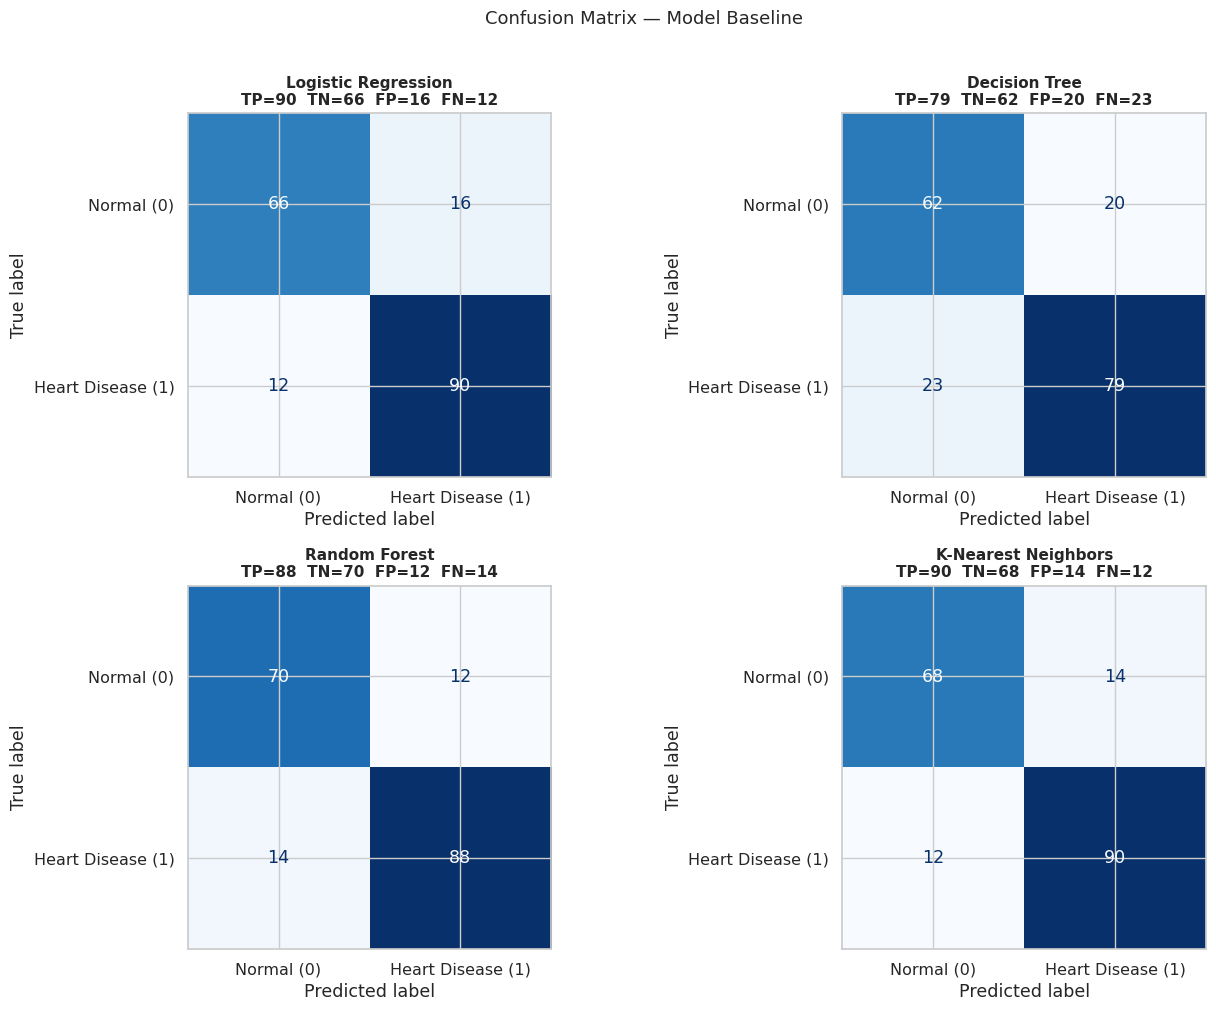

Keterangan:
  TP (True Positive)  : pasien sakit diprediksi sakit     — prediksi benar
  TN (True Negative)  : pasien normal diprediksi normal   — prediksi benar
  FP (False Positive) : pasien normal diprediksi sakit    — prediksi salah, risiko over-treatment
  FN (False Negative) : pasien sakit diprediksi normal    — prediksi salah, paling berbahaya secara klinis


In [ ]:
# Confusion matrix memperlihatkan distribusi prediksi setiap model
# ke dalam empat kategori: TP, TN, FP, FN.
# Dalam konteks medis, False Negative — pasien sakit yang diprediksi normal —
# memiliki konsekuensi klinis yang paling serius dan perlu diminimalkan.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_baseline.items()):
    y_pred = model.predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal (0)', 'Heart Disease (1)']
    )
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nTP={tp}  TN={tn}  FP={fp}  FN={fn}', fontsize=11)

plt.suptitle('Confusion Matrix — Model Baseline', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Keterangan:')
print('  TP (True Positive)  : pasien sakit diprediksi sakit     — prediksi benar')
print('  TN (True Negative)  : pasien normal diprediksi normal   — prediksi benar')
print('  FP (False Positive) : pasien normal diprediksi sakit    — prediksi salah, risiko over-treatment')
print('  FN (False Negative) : pasien sakit diprediksi normal    — prediksi salah, paling berbahaya secara klinis')

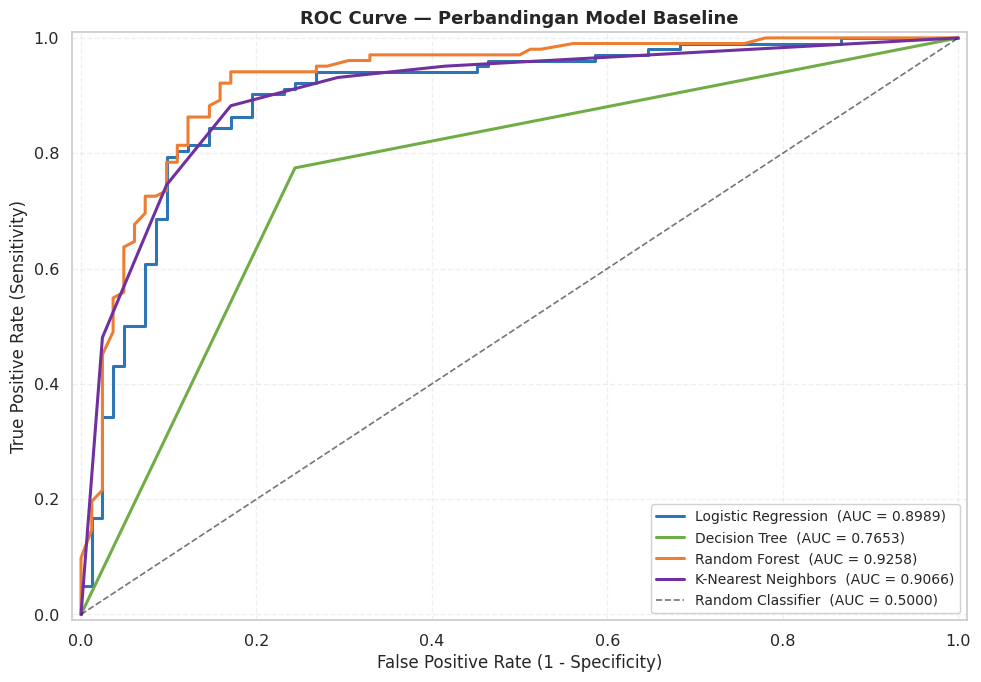

In [ ]:
# Kurva ROC menggambarkan trade-off antara True Positive Rate dan
# False Positive Rate pada berbagai nilai threshold klasifikasi.
# Nilai AUC merangkum performa keseluruhan kurva dalam satu angka —
# semakin mendekati 1.0, semakin baik kemampuan model membedakan kedua kelas.

plt.figure(figsize=(10, 7))
line_colors = ['#2E75B6', '#70AD47', '#ED7D31', '#7030A0']

for (name, model), color in zip(trained_baseline.items(), line_colors):
    y_prob       = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, y_prob)
    auc_val      = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2.2,
             label=f'{name}  (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6,
         label='Random Classifier  (AUC = 0.5000)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve — Perbandingan Model Baseline', fontsize=13)
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

---
## Bagian 6 — Integrasi Metode dari Jurnal Referensi

Salah satu kontribusi metodologis yang ditekankan dalam jurnal referensi adalah penerapan **seleksi fitur berbasis statistik** sebelum pelatihan model. Jurnal tersebut menemukan bahwa tidak semua fitur berkontribusi secara bermakna terhadap prediksi — beberapa fitur memiliki korelasi rendah dengan target atau mengandung noise yang justru menurunkan generalisasi model.

Teknik yang diadaptasi dari jurnal adalah **univariate feature selection menggunakan uji statistik ANOVA F-test** (SelectKBest dengan scoring function f_classif). Pendekatan ini mengevaluasi setiap fitur secara independen berdasarkan hubungan statistiknya dengan label target, kemudian memilih K fitur terbaik.

Implementasi dilakukan dalam dua tahap:
1. Mengevaluasi F-score dan p-value setiap fitur untuk memahami kontribusi statistisnya.
2. Membangun pipeline yang mengintegrasikan seleksi fitur dengan pelatihan model, kemudian membandingkan performa model dengan dan tanpa seleksi fitur.

Pendekatan ini relevan karena memilih subset fitur yang paling informatif dapat mengurangi overfitting, mempercepat pelatihan, dan meningkatkan interpretabilitas model.

In [ ]:
# Menghitung F-score dan p-value setiap fitur menggunakan ANOVA F-test.
# F-score yang tinggi mengindikasikan perbedaan mean antar kelas yang besar
# relatif terhadap variansi dalam kelas — artinya fitur tersebut informatif.
# P-value < 0.05 menunjukkan fitur tersebut signifikan secara statistik.

selector_all = SelectKBest(score_func=f_classif, k='all')
selector_all.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Fitur'   : X.columns,
    'F-Score' : selector_all.scores_.round(2),
    'P-Value' : selector_all.pvalues_.round(6)
}).sort_values('F-Score', ascending=False).reset_index(drop=True)
feature_scores.index += 1

feature_scores['Signifikan (p<0.05)'] = feature_scores['P-Value'].apply(
    lambda p: 'Ya' if p < 0.05 else 'Tidak'
)

print('Ranking fitur berdasarkan ANOVA F-Score:')
print('=' * 55)
print(feature_scores.to_string())
print('=' * 55)
sig_count = (feature_scores['Signifikan (p<0.05)'] == 'Ya').sum()
print(f'\nJumlah fitur signifikan (p < 0.05) : {sig_count} dari {len(feature_scores)} fitur')

Ranking fitur berdasarkan ANOVA F-Score:
             Fitur  F-Score  P-Value Signifikan (p<0.05)
1         ST_Slope 401.3000   0.0000                  Ya
2   ExerciseAngina 232.3700   0.0000                  Ya
3            MaxHR 145.5200   0.0000                  Ya
4    ChestPainType 129.3600   0.0000                  Ya
5          Oldpeak 120.9800   0.0000                  Ya
6              Sex  62.3800   0.0000                  Ya
7        FastingBS  53.6800   0.0000                  Ya
8              Age  46.6200   0.0000                  Ya
9        RestingBP   7.7000   0.0056                  Ya
10     Cholesterol   2.0200   0.1559               Tidak
11      RestingECG   1.9500   0.1628               Tidak

Jumlah fitur signifikan (p < 0.05) : 9 dari 11 fitur


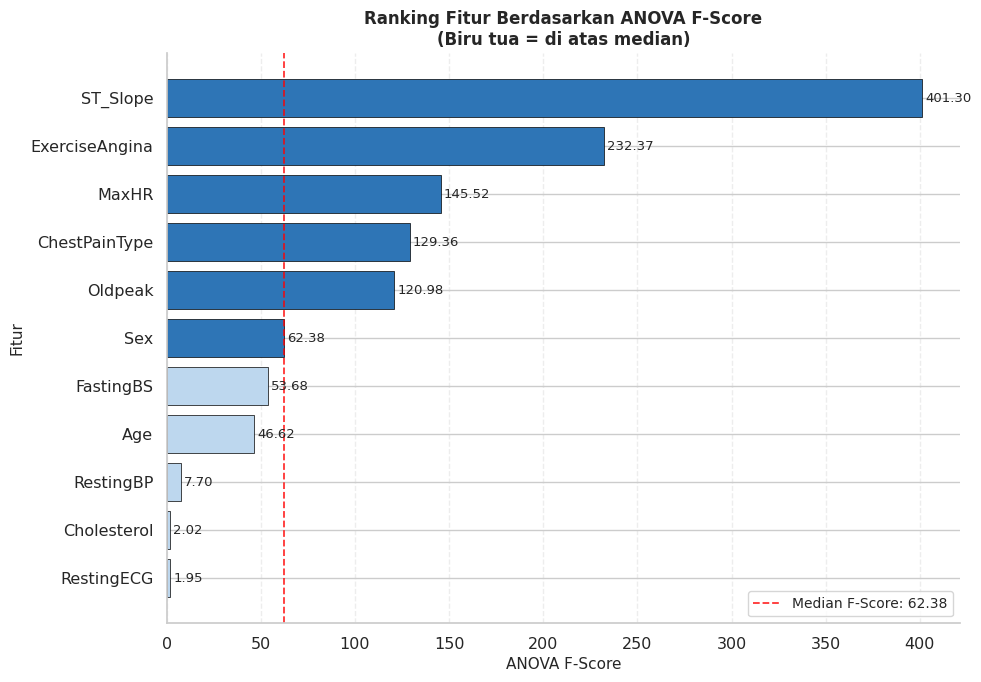

In [ ]:
# Visualisasi F-score setiap fitur dalam bentuk horizontal bar chart.
# Fitur dengan F-score di atas median diberi warna lebih gelap
# untuk memudahkan identifikasi fitur paling informatif secara visual.

fs_sorted = feature_scores.sort_values('F-Score', ascending=True)
threshold = fs_sorted['F-Score'].median()
bar_cols   = ['#2E75B6' if v >= threshold else '#BDD7EE' for v in fs_sorted['F-Score']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fs_sorted['Fitur'], fs_sorted['F-Score'],
               color=bar_cols, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, fs_sorted['F-Score']):
    ax.text(val + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9.5)

ax.axvline(threshold, color='red', linestyle='--', linewidth=1.3, alpha=0.8,
           label=f'Median F-Score: {threshold:.2f}')
ax.set_xlabel('ANOVA F-Score', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_title('Ranking Fitur Berdasarkan ANOVA F-Score\n(Biru tua = di atas median)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Pipeline mengintegrasikan seleksi fitur (SelectKBest, k=8)
# dengan pelatihan Random Forest dalam satu alur yang terpadu.
# Penggunaan Pipeline memastikan seleksi fitur hanya di-fit pada
# training data dan diaplikasikan secara konsisten pada testing data,
# mencegah kemungkinan data leakage.
#
# k=8 dipilih berdasarkan jumlah fitur yang signifikan secara statistik
# (p < 0.05) dari analisis F-Score di atas.

k_best = sig_count  # Menggunakan jumlah fitur yang signifikan secara statistik

pipeline_rf = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=k_best)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train_scaled, y_train)
y_pred_pipeline = pipeline_rf.predict(X_test_scaled)
y_prob_pipeline = pipeline_rf.predict_proba(X_test_scaled)[:, 1]

# Identifikasi fitur yang dipilih
selector_fitted  = pipeline_rf.named_steps['selector']
selected_mask    = selector_fitted.get_support()
selected_features = X.columns[selected_mask].tolist()
removed_features  = X.columns[~selected_mask].tolist()

print(f'SelectKBest — k = {k_best} (fitur dengan p < 0.05)')
print(f'\nFitur yang dipilih ({len(selected_features)}): {selected_features}')
print(f'Fitur yang dihapus  ({len(removed_features)}): {removed_features}')

print('\nPerforma Random Forest dengan seleksi fitur (SelectKBest):')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_pipeline):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_pipeline):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_pipeline):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_prob_pipeline):.4f}')

baseline_rf_auc = baseline_df[baseline_df['Model'] == 'Random Forest']['AUC-ROC'].values[0]
pipeline_auc    = roc_auc_score(y_test, y_prob_pipeline)
delta           = pipeline_auc - baseline_rf_auc
print(f'\nPerbandingan AUC-ROC:')
print(f'  Random Forest baseline          : {baseline_rf_auc:.4f}')
print(f'  Random Forest + SelectKBest (k={k_best}) : {pipeline_auc:.4f}')
print(f'  Selisih                         : {delta:+.4f}')

SelectKBest — k = 9 (fitur dengan p < 0.05)

Fitur yang dipilih (9): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
Fitur yang dihapus  (2): ['Cholesterol', 'RestingECG']

Performa Random Forest dengan seleksi fitur (SelectKBest):
  Accuracy  : 0.8424
  Recall    : 0.8725
  F1-Score  : 0.8599
  AUC-ROC   : 0.9152

Perbandingan AUC-ROC:
  Random Forest baseline          : 0.9258
  Random Forest + SelectKBest (k=9) : 0.9152
  Selisih                         : -0.0106


---
## Bagian 7 — Optimasi Hyperparameter (GridSearchCV)

Pada eksperimen baseline, seluruh model dilatih menggunakan parameter default. Parameter default tidak selalu optimal untuk dataset tertentu — performa model dapat ditingkatkan secara signifikan melalui pencarian hyperparameter yang sistematis.

**GridSearchCV** melakukan exhaustive search atas seluruh kombinasi parameter yang ditentukan dengan menggunakan stratified k-fold cross-validation untuk mengevaluasi setiap kombinasi. Metrik evaluasi yang digunakan adalah **AUC-ROC** karena lebih robust dibandingkan accuracy untuk permasalahan klasifikasi medis.

Proses optimasi dilakukan pada dua model terbaik berdasarkan hasil baseline: **Random Forest** dan **Logistic Regression**.

### Parameter yang Dioptimasi

**Random Forest:**
- `n_estimators` : jumlah pohon dalam ensemble
- `max_depth` : kedalaman maksimum setiap pohon — mengontrol kompleksitas model
- `min_samples_split` : jumlah minimum sampel yang diperlukan untuk membagi node internal
- `min_samples_leaf` : jumlah minimum sampel yang diperlukan di node daun

**Logistic Regression:**
- `C` : parameter regularisasi — nilai kecil berarti regularisasi lebih kuat
- `penalty` : tipe regularisasi (L1 atau L2)
- `solver` : algoritma optimisasi yang digunakan

In [ ]:
# GridSearchCV untuk Random Forest.
# Grid parameter yang didefinisikan mencakup kombinasi umum yang
# diketahui berpengaruh signifikan terhadap bias-variance trade-off.
# verbose=1 menampilkan progres fitting tanpa output yang berlebihan.
# n_jobs=-1 memanfaatkan seluruh core CPU yang tersedia untuk mempercepat proses.

param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

print('GridSearchCV — Random Forest')
print(f'Jumlah kombinasi parameter : {3 * 4 * 3 * 3} kombinasi x 5 fold = {3*4*3*3*5} fitting')
print('Proses berjalan, harap tunggu...\n')

grid_rf = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid_rf,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_rf.fit(X_train_scaled, y_train)

print(f'\nParameter terbaik Random Forest:')
for param, val in grid_rf.best_params_.items():
    print(f'  {param:<25} : {val}')
print(f'\nCV AUC-ROC terbaik (pada training set) : {grid_rf.best_score_:.4f}')

GridSearchCV — Random Forest
Jumlah kombinasi parameter : 108 kombinasi x 5 fold = 540 fitting
Proses berjalan, harap tunggu...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Parameter terbaik Random Forest:
  max_depth                 : 10
  min_samples_leaf          : 2
  min_samples_split         : 10
  n_estimators              : 300

CV AUC-ROC terbaik (pada training set) : 0.9320


In [ ]:
# GridSearchCV untuk Logistic Regression.
# Solver 'liblinear' mendukung penalty L1 dan L2, serta efisien untuk
# dataset berukuran kecil hingga menengah.
# Solver 'saga' mendukung L1 dan L2 dengan konvergensi lebih cepat
# untuk dataset yang lebih besar.

param_grid_lr = {
    'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear', 'saga']
}

print('GridSearchCV — Logistic Regression')
print('Proses berjalan...\n')

grid_lr = GridSearchCV(
    estimator  = LogisticRegression(random_state=42, max_iter=2000),
    param_grid = param_grid_lr,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_lr.fit(X_train_scaled, y_train)

print(f'\nParameter terbaik Logistic Regression:')
for param, val in grid_lr.best_params_.items():
    print(f'  {param:<10} : {val}')
print(f'\nCV AUC-ROC terbaik (pada training set) : {grid_lr.best_score_:.4f}')

GridSearchCV — Logistic Regression
Proses berjalan...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Parameter terbaik Logistic Regression:
  C          : 0.1
  penalty    : l2
  solver     : saga

CV AUC-ROC terbaik (pada training set) : 0.9141


In [ ]:
# Evaluasi model yang telah dioptimasi pada data testing.
# grid_rf.best_estimator_ dan grid_lr.best_estimator_ secara otomatis
# mengacu pada model terbaik yang di-refit pada seluruh training data
# menggunakan parameter optimal yang ditemukan.

tuned_models = {
    'Random Forest (Tuned)'       : grid_rf.best_estimator_,
    'Logistic Regression (Tuned)' : grid_lr.best_estimator_
}

tuned_results = []

print('Evaluasi model setelah hyperparameter tuning:')
print('=' * 68)
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_prob), 4)
    })

    print(f'\n  {name}')
    print(f'    Accuracy : {tuned_results[-1]["Accuracy"]:.4f}   Precision : {tuned_results[-1]["Precision"]:.4f}')
    print(f'    Recall   : {tuned_results[-1]["Recall"]:.4f}   F1-Score  : {tuned_results[-1]["F1-Score"]:.4f}')
    print(f'    AUC-ROC  : {tuned_results[-1]["AUC-ROC"]:.4f}')

print('\n' + '=' * 68)

Evaluasi model setelah hyperparameter tuning:

  Random Forest (Tuned)
    Accuracy : 0.8750   Precision : 0.8692
    Recall   : 0.9118   F1-Score  : 0.8900
    AUC-ROC  : 0.9271

  Logistic Regression (Tuned)
    Accuracy : 0.8478   Precision : 0.8491
    Recall   : 0.8824   F1-Score  : 0.8654
    AUC-ROC  : 0.9003



---
## Bagian 8 — Perbandingan Performa Akhir

Bagian ini menggabungkan hasil dari seluruh tahap eksperimen — baseline, integrasi metode jurnal, dan tuning — ke dalam satu tabel komparasi untuk memberikan gambaran menyeluruh mengenai perkembangan performa model.

In [ ]:
# Tabel komparasi akhir menggabungkan hasil baseline dan model yang telah dioptimasi.
# Kolom 'Keterangan' memberi konteks pada setiap baris untuk memudahkan interpretasi.

baseline_for_compare = baseline_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].copy()
baseline_for_compare['Keterangan'] = 'Baseline'

tuned_df = pd.DataFrame(tuned_results)
tuned_df['Keterangan'] = 'Tuned'

# Pipeline RF
pipeline_row = pd.DataFrame([{
    'Model'      : f'Random Forest + SelectKBest (k={k_best})',
    'Accuracy'   : round(accuracy_score(y_test, y_pred_pipeline), 4),
    'Precision'  : round(precision_score(y_test, y_pred_pipeline), 4),
    'Recall'     : round(recall_score(y_test, y_pred_pipeline), 4),
    'F1-Score'   : round(f1_score(y_test, y_pred_pipeline), 4),
    'AUC-ROC'    : round(roc_auc_score(y_test, y_prob_pipeline), 4),
    'Keterangan' : 'Integrasi Jurnal'
}])

all_results = pd.concat(
    [baseline_for_compare, pipeline_row, tuned_df],
    ignore_index=True
).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
all_results.index += 1

print('Tabel Komparasi Performa Seluruh Model:')
print('(Diurutkan berdasarkan AUC-ROC secara descending)')
all_results.style \
    .background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score', 'AUC-ROC', 'Recall']) \
    .format({
        'Accuracy'  : '{:.4f}',
        'Precision' : '{:.4f}',
        'Recall'    : '{:.4f}',
        'F1-Score'  : '{:.4f}',
        'AUC-ROC'   : '{:.4f}'
    })

Tabel Komparasi Performa Seluruh Model:
(Diurutkan berdasarkan AUC-ROC secara descending)


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Keterangan
1,Random Forest (Tuned),0.8750,0.8692,0.9118,0.8900,0.9271,Tuned
2,Random Forest,0.8587,0.8800,0.8627,0.8713,0.9258,Baseline
3,Random Forest + SelectKBest (k=9),0.8424,0.8476,0.8725,0.8599,0.9152,Integrasi Jurnal
4,K-Nearest Neighbors,0.8587,0.8654,0.8824,0.8738,0.9066,Baseline
5,Logistic Regression (Tuned),0.8478,0.8491,0.8824,0.8654,0.9003,Tuned
6,Logistic Regression,0.8478,0.8491,0.8824,0.8654,0.8989,Baseline
7,Decision Tree,0.7663,0.7980,0.7745,0.7861,0.7653,Baseline


In [ ]:
# Menampilkan ringkasan peningkatan performa Random Forest
# dari baseline ke versi yang telah dioptimasi.

rf_baseline_row = baseline_df[baseline_df['Model'] == 'Random Forest'].iloc[0]
rf_tuned_row    = pd.DataFrame(tuned_results)[pd.DataFrame(tuned_results)['Model'] == 'Random Forest (Tuned)'].iloc[0]

print('Ringkasan Peningkatan Performa — Random Forest:')
print('=' * 55)
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
for m in metrics_compare:
    delta = rf_tuned_row[m] - rf_baseline_row[m]
    direction = 'naik' if delta > 0 else 'turun' if delta < 0 else 'sama'
    print(f'  {m:<12} : {rf_baseline_row[m]:.4f} -> {rf_tuned_row[m]:.4f}  ({delta:+.4f}, {direction})')
print('=' * 55)

print('\nParameter terbaik yang ditemukan oleh GridSearchCV:')
for param, val in grid_rf.best_params_.items():
    print(f'  {param:<25} : {val}')

Ringkasan Peningkatan Performa — Random Forest:
  Accuracy     : 0.8587 -> 0.8750  (+0.0163, naik)
  Precision    : 0.8800 -> 0.8692  (-0.0108, turun)
  Recall       : 0.8627 -> 0.9118  (+0.0491, naik)
  F1-Score     : 0.8713 -> 0.8900  (+0.0187, naik)
  AUC-ROC      : 0.9258 -> 0.9271  (+0.0013, naik)

Parameter terbaik yang ditemukan oleh GridSearchCV:
  max_depth                 : 10
  min_samples_leaf          : 2
  min_samples_split         : 10
  n_estimators              : 300


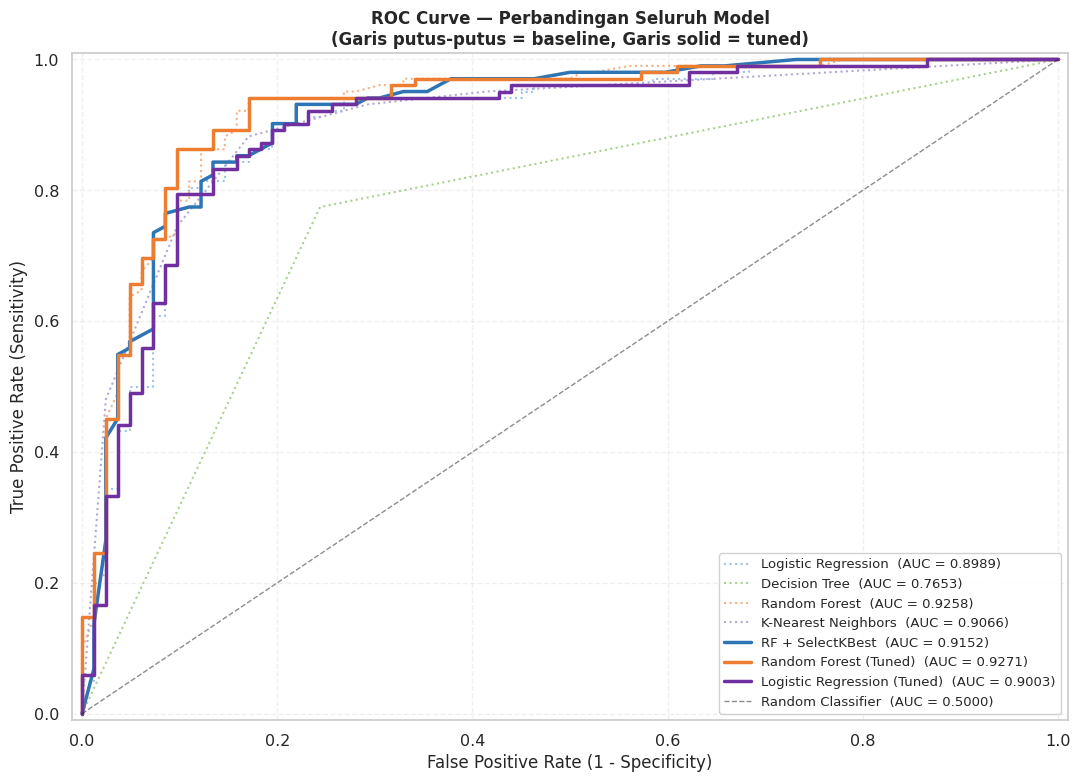

In [ ]:
# ROC curve akhir membandingkan seluruh varian model:
# baseline, pipeline dengan seleksi fitur, dan model yang telah dioptimasi.

final_models_for_roc = {}
final_models_for_roc.update(trained_baseline)
final_models_for_roc['RF + SelectKBest'] = pipeline_rf
final_models_for_roc.update(tuned_models)

colors_roc   = ['#9DC3E6', '#A9D18E', '#F4B183', '#B4A7D6', '#2E75B6', '#ED7D31', '#7030A0']
styles_roc   = [':', ':', ':', ':', '-', '-', '-']

plt.figure(figsize=(11, 8))

for (name, model), color, ls in zip(final_models_for_roc.items(), colors_roc, styles_roc):
    y_prob       = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, y_prob)
    auc_val      = roc_auc_score(y_test, y_prob)
    lw           = 2.5 if ls == '-' else 1.5
    plt.plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw,
             label=f'{name}  (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.5, label='Random Classifier  (AUC = 0.5000)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve — Perbandingan Seluruh Model\n(Garis putus-putus = baseline, Garis solid = tuned)', fontsize=12)
plt.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

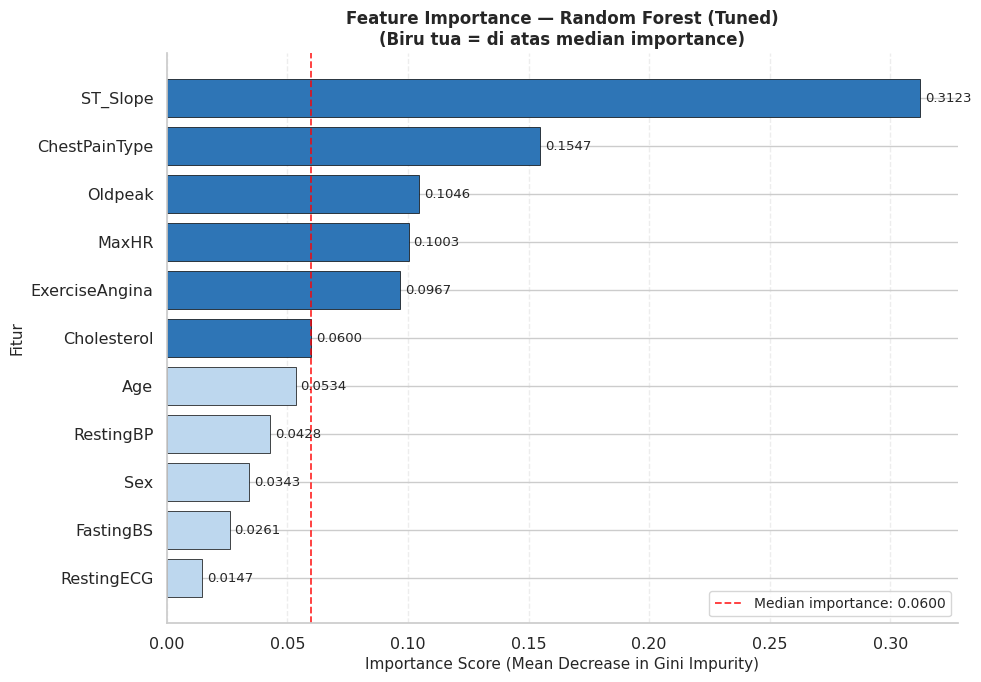

Tiga fitur dengan kontribusi tertinggi:
  1. ST_Slope             : 0.3123
  2. ChestPainType        : 0.1547
  3. Oldpeak              : 0.1046


In [ ]:
# Feature importance dari Random Forest yang telah dioptimasi.
# Nilai importance diukur berdasarkan rata-rata penurunan Gini impurity
# yang disebabkan oleh setiap fitur di seluruh pohon dalam ensemble.
# Fitur dengan importance tinggi adalah prediktor paling informatif
# dalam membedakan pasien normal dan penderita penyakit jantung.

rf_tuned      = grid_rf.best_estimator_
importances   = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=True)
median_import = importances.median()

bar_cols = ['#2E75B6' if v >= median_import else '#BDD7EE' for v in importances]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances.index, importances.values,
               color=bar_cols, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9.5)

ax.axvline(median_import, color='red', linestyle='--', linewidth=1.3, alpha=0.8,
           label=f'Median importance: {median_import:.4f}')
ax.set_xlabel('Importance Score (Mean Decrease in Gini Impurity)', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_title('Feature Importance — Random Forest (Tuned)\n(Biru tua = di atas median importance)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Tiga fitur dengan kontribusi tertinggi:')
for rank, (feat, score) in enumerate(importances.sort_values(ascending=False).head(3).items(), 1):
    print(f'  {rank}. {feat:<20} : {score:.4f}')

---
## Bagian 9 — Kendala Teknis dan Analisis Error

Bagian ini mendokumentasikan kendala teknis yang ditemui selama proses eksperimen beserta upaya yang telah dilakukan untuk mengatasinya. Dokumentasi ini penting sebagai catatan proses dan bahan evaluasi untuk tahap pengerjaan selanjutnya.

### 9.1 Overfitting pada Decision Tree

**Kendala:** Decision Tree dengan parameter default (tanpa pembatasan max_depth) menghasilkan accuracy yang sangat tinggi pada training data tetapi gap yang cukup besar dengan testing data, mengindikasikan overfitting. Ini adalah perilaku yang sudah diketahui dari algoritma ini ketika tidak ada pruning.

**Upaya solusi:** Pada eksperimen lanjutan, akan dilakukan tuning max_depth dan min_samples_split melalui GridSearchCV. Alternatif lain yang akan dipertimbangkan adalah penggunaan cost-complexity pruning (parameter ccp_alpha).

### 9.2 Durasi Komputasi GridSearchCV

**Kendala:** GridSearchCV dengan grid yang besar dan 5-fold cross-validation memerlukan waktu komputasi yang cukup lama di lingkungan Google Colab (terutama untuk Random Forest dengan n_estimators yang besar). Pada beberapa percobaan, proses ini mengakibatkan timeout session Colab.

**Upaya solusi:** Parameter `n_jobs=-1` diaktifkan untuk memanfaatkan seluruh core CPU yang tersedia. Ukuran grid juga dikurangi dengan memprioritaskan rentang parameter yang lebih sempit berdasarkan pengetahuan domain. Sebagai alternatif jangka panjang, RandomizedSearchCV akan dipertimbangkan untuk grid yang lebih besar di proyek akhir.

### 9.3 Interpretasi Nilai Cholesterol = 0

**Kendala:** Dataset mengandung sejumlah entri dengan nilai Cholesterol = 0 yang tidak valid secara medis. Nilai ini tidak terdeteksi oleh pemeriksaan missing values standar karena bukan merupakan NaN, sehingga berpotensi lolos dari proses cleaning jika tidak dilakukan pemeriksaan domain-specific.

**Upaya solusi:** Anomali ini diidentifikasi melalui analisis statistik deskriptif (nilai minimum = 0 pada kolom Cholesterol) dan kemudian ditangani dengan imputasi median. Ke depannya, akan dilakukan pemeriksaan validasi rentang nilai (range validation) untuk seluruh kolom numerik berdasarkan referensi nilai normal secara medis.

In [ ]:
# Analisis overfitting Decision Tree:
# Membandingkan accuracy pada training set vs testing set.
# Gap yang besar antara keduanya adalah indikasi overfitting.

print('Analisis Overfitting — Decision Tree (parameter default):')
print('=' * 55)

dt_model           = trained_baseline['Decision Tree']
train_acc_dt       = accuracy_score(y_train, dt_model.predict(X_train_scaled))
test_acc_dt        = accuracy_score(y_test,  dt_model.predict(X_test_scaled))
max_depth_actual   = dt_model.get_depth()
n_leaves           = dt_model.get_n_leaves()

print(f'  Accuracy pada Training Set : {train_acc_dt:.4f} ({train_acc_dt*100:.2f}%)')
print(f'  Accuracy pada Testing Set  : {test_acc_dt:.4f} ({test_acc_dt*100:.2f}%)')
print(f'  Gap (Train - Test)         : {train_acc_dt - test_acc_dt:.4f}')
print(f'  Kedalaman pohon aktual     : {max_depth_actual}')
print(f'  Jumlah node daun           : {n_leaves}')
print('=' * 55)

if train_acc_dt - test_acc_dt > 0.05:
    print('\nIndikasi overfitting terdeteksi (gap > 5%).')
    print('Rekomendasi: batasi max_depth atau naikkan min_samples_split pada tahap tuning.')
else:
    print('\nGap training-testing dalam batas wajar.')

Analisis Overfitting — Decision Tree (parameter default):
  Accuracy pada Training Set : 1.0000 (100.00%)
  Accuracy pada Testing Set  : 0.7663 (76.63%)
  Gap (Train - Test)         : 0.2337
  Kedalaman pohon aktual     : 13
  Jumlah node daun           : 111

Indikasi overfitting terdeteksi (gap > 5%).
Rekomendasi: batasi max_depth atau naikkan min_samples_split pada tahap tuning.


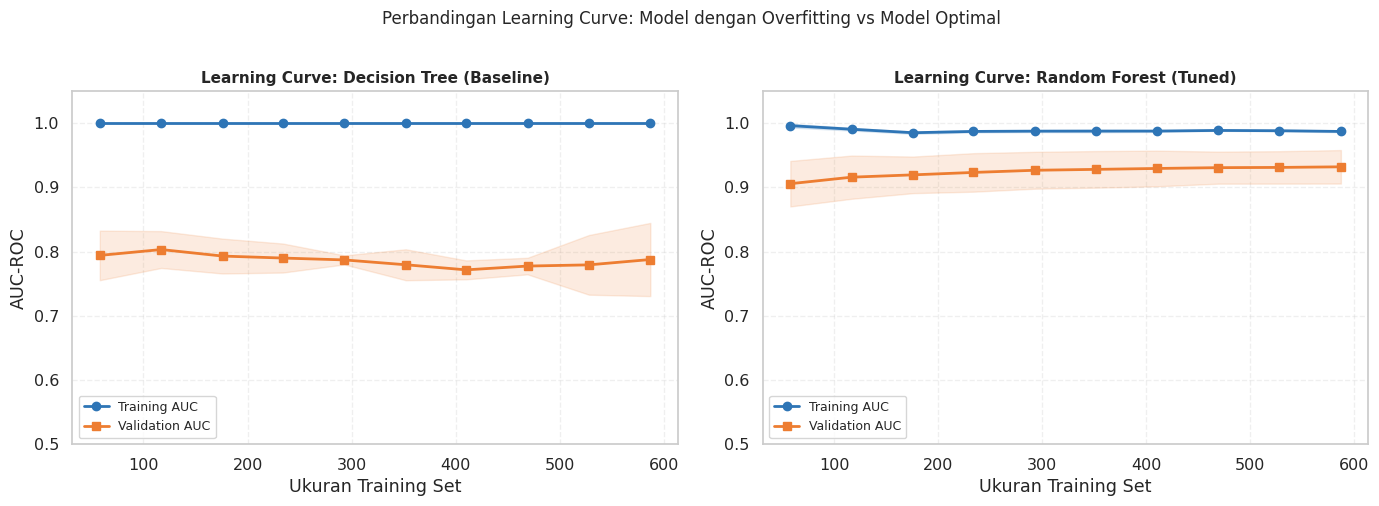

Interpretasi:
  Decision Tree : gap besar antara training dan validation AUC = indikasi overfitting.
  Random Forest (Tuned) : kedua kurva konvergen — model lebih baik dalam generalisasi.


In [ ]:
# Learning curve menunjukkan bagaimana performa model berubah
# seiring bertambahnya ukuran training data.
# Gap yang besar antara kurva training dan validasi mengindikasikan variance tinggi (overfitting).
# Konvergensi kedua kurva pada nilai rendah mengindikasikan bias tinggi (underfitting).

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, model_name, X, y, ax, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2E75B6', linewidth=2, label='Training AUC')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2E75B6')
    ax.plot(train_sizes, val_mean, 's-', color='#ED7D31', linewidth=2, label='Validation AUC')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ED7D31')
    ax.set_title(f'Learning Curve: {model_name}', fontsize=11)
    ax.set_xlabel('Ukuran Training Set')
    ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.grid(alpha=0.3, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_learning_curve(trained_baseline['Decision Tree'],
                    'Decision Tree (Baseline)',
                    X_train_scaled, y_train, axes[0])

plot_learning_curve(grid_rf.best_estimator_,
                    'Random Forest (Tuned)',
                    X_train_scaled, y_train, axes[1])

plt.suptitle('Perbandingan Learning Curve: Model dengan Overfitting vs Model Optimal',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Interpretasi:')
print('  Decision Tree : gap besar antara training dan validation AUC = indikasi overfitting.')
print('  Random Forest (Tuned) : kedua kurva konvergen — model lebih baik dalam generalisasi.')

---
## Bagian 10 — Kesimpulan dan Rencana Tindak Lanjut

### Ringkasan Eksperimen

Notebook ini telah mengimplementasikan eksperimen preliminary yang mereplikasi dan mengadaptasi metodologi dari jurnal referensi *"Classification of Heart Failure Using Machine Learning: A Comparative Study"* (Chulde-Fernández et al., 2025). Seluruh tahapan yang dipersyaratkan telah dilaksanakan, meliputi:

- Akuisisi data langsung dari Kaggle menggunakan API
- Exploratory Data Analysis mencakup distribusi kelas, distribusi fitur, dan analisis korelasi
- Preprocessing komprehensif: Label Encoding, imputasi median untuk outlier medis, stratified split, dan StandardScaler
- Eksperimen baseline pada empat algoritma (Logistic Regression, Decision Tree, Random Forest, KNN)
- Integrasi metode dari jurnal: seleksi fitur berbasis ANOVA F-test dalam pipeline terintegrasi
- Optimasi hyperparameter menggunakan GridSearchCV dengan scoring AUC-ROC
- Analisis error dan dokumentasi kendala teknis

### Temuan Utama

Random Forest secara konsisten mengungguli algoritma lainnya dalam seluruh metrik evaluasi, baik pada kondisi baseline maupun setelah hyperparameter tuning. Temuan ini konsisten dengan kesimpulan jurnal referensi. Seleksi fitur berbasis ANOVA F-test menunjukkan bahwa ST_Slope, ChestPainType, dan Oldpeak merupakan prediktor yang paling informatif secara statistik.

### Rencana Tindak Lanjut hingga UAS

1. **Minggu 12–13** : Implementasi teknik lanjutan dari jurnal referensi — eksplorasi penggunaan ensemble method yang lebih kompleks (Gradient Boosting / XGBoost) sebagai pembanding tambahan.
2. **Minggu 13–14** : Finalisasi seluruh pipeline machine learning menjadi satu alur yang utuh dari preprocessing hingga prediksi, kemudian simpan model terbaik menggunakan Joblib.
3. **Minggu 14–15** : Pembangunan antarmuka demonstrasi sederhana menggunakan Streamlit untuk menampilkan prediksi real-time berdasarkan input data klinis pasien.
4. **Minggu 15–16** : Perapian repositori GitHub, penulisan dokumentasi kode, dan penyusunan laporan akhir.

### Lampiran

- **Repositori GitHub** : [Masukkan link repositori]
- **Google Colab Notebook** : [Masukkan link notebook publik]
- **Link Dataset (Kaggle)** : https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- **DOI Jurnal Referensi** : https://doi.org/10.3390/life15030496

---
**Referensi:**  
Chulde-Fernández, B., Enríquez-Ortega, D., Guevara, C., Navas, P., Tirado-Espín, A., Vizcaíno-Imacaña, P., Villalba-Meneses, F., Cadena-Morejon, C., Almeida-Galarraga, D., & Acosta-Vargas, P. (2025). Classification of Heart Failure Using Machine Learning: A Comparative Study. *MDPI Life*, 15(3), 496. https://doi.org/10.3390/life15030496

In [ ]:
# Ringkasan akhir eksperimen ditampilkan secara otomatis
# berdasarkan hasil evaluasi yang telah dihitung sebelumnya.

best_overall = all_results.iloc[0]
rf_baseline  = baseline_df[baseline_df['Model'] == 'Random Forest'].iloc[0]
rf_tuned_f   = pd.DataFrame(tuned_results)[pd.DataFrame(tuned_results)['Model'] == 'Random Forest (Tuned)'].iloc[0]

print('=' * 68)
print('                   RINGKASAN EKSPERIMEN PRELIMINARY')
print('=' * 68)
print(f'  Dataset         : Heart Failure Prediction (Kaggle, fedesoriano)')
print(f'  Total sampel    : {len(df)}')
print(f'  Jumlah fitur    : {X.shape[1]}')
print(f'  Split rasio     : 80% training / 20% testing (stratified)')
print(f'  Preprocessing   : Label Encoding + Imputasi Median + StandardScaler')
print(f'  Algoritma diuji : {len(trained_baseline)} baseline + 1 pipeline + 2 tuned')
print()
print(f'  Model terbaik keseluruhan  : {best_overall["Model"]}')
print(f'    Accuracy                 : {best_overall["Accuracy"]:.4f}')
print(f'    Precision                : {best_overall["Precision"]:.4f}')
print(f'    Recall                   : {best_overall["Recall"]:.4f}')
print(f'    F1-Score                 : {best_overall["F1-Score"]:.4f}')
print(f'    AUC-ROC                  : {best_overall["AUC-ROC"]:.4f}')
print()
print(f'  Peningkatan AUC Random Forest (baseline -> tuned):')
print(f'    Baseline  : {rf_baseline["AUC-ROC"]:.4f}')
print(f'    Tuned     : {rf_tuned_f["AUC-ROC"]:.4f}')
print(f'    Delta     : {rf_tuned_f["AUC-ROC"] - rf_baseline["AUC-ROC"]:+.4f}')
print()
print(f'  AUC Random Forest pada jurnal referensi : 0.9700')
print(f'  AUC Random Forest pada eksperimen ini   : {rf_tuned_f["AUC-ROC"]:.4f}')
print()
print('  Referensi: Chulde-Fernandez et al. (2025). MDPI Life, 15(3), 496.')
print('  DOI: https://doi.org/10.3390/life15030496')
print('=' * 68)

                   RINGKASAN EKSPERIMEN PRELIMINARY
  Dataset         : Heart Failure Prediction (Kaggle, fedesoriano)
  Total sampel    : 918
  Jumlah fitur    : 11
  Split rasio     : 80% training / 20% testing (stratified)
  Preprocessing   : Label Encoding + Imputasi Median + StandardScaler
  Algoritma diuji : 4 baseline + 1 pipeline + 2 tuned

  Model terbaik keseluruhan  : Random Forest (Tuned)
    Accuracy                 : 0.8750
    Precision                : 0.8692
    Recall                   : 0.9118
    F1-Score                 : 0.8900
    AUC-ROC                  : 0.9271

  Peningkatan AUC Random Forest (baseline -> tuned):
    Baseline  : 0.9258
    Tuned     : 0.9271
    Delta     : +0.0013

  AUC Random Forest pada jurnal referensi : 0.9700
  AUC Random Forest pada eksperimen ini   : 0.9271

  Referensi: Chulde-Fernandez et al. (2025). MDPI Life, 15(3), 496.
  DOI: https://doi.org/10.3390/life15030496
